In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import functions
import glob as glob

In [30]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'
ds_piClim = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.radiation.cam.concatfiles.nc')
ds_0_5xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_0_5xCO2_20250529.radiation.cam.concatfiles.nc')
ds_2xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.radiation.cam.concatfiles.nc')
ds_4xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.radiation.cam.concatfiles.nc')

In [31]:
# Fix time stamp
ds_piClim = functions.fix_cam_time(ds_piClim)
ds_0_5xCO2 = functions.fix_cam_time(ds_0_5xCO2)
ds_2xCO2 = functions.fix_cam_time(ds_2xCO2)
ds_4xCO2 = functions.fix_cam_time(ds_4xCO2)

In [60]:
tslice = slice('2040-01-01','2069-12-31')
ds_list = []
for ds in [ds_piClim, ds_0_5xCO2, ds_2xCO2, ds_4xCO2]:

    ds = ds.sel(time=tslice)
    ds = ds.groupby('time.month').mean('time')
    ds = ds.rename({'month':'time'})
    ds['LWCRE_surf'] = -ds['FLNS']+ds['FLNSC']
    ds['LWCRE_toa'] = -ds['FLNT']+ds['FLNTC']
    ds_list.append(ds)

ds = xr.concat(ds_list, dim='co2_conc')
ds = ds.assign_coords({'co2_conc':['piClim','0.5xCO2', '2xCO2', '4xCO2']})


(array([13232., 40537., 27342., 18952., 14213., 13395., 16132., 13933.,
         7325.,   827.]),
 array([4.13513184e-02, 7.69407654e+00, 1.53468018e+01, 2.29995270e+01,
        3.06522522e+01, 3.83049774e+01, 4.59577026e+01, 5.36104279e+01,
        6.12631531e+01, 6.89158783e+01, 7.65686035e+01]),
 <BarContainer object of 10 artists>)

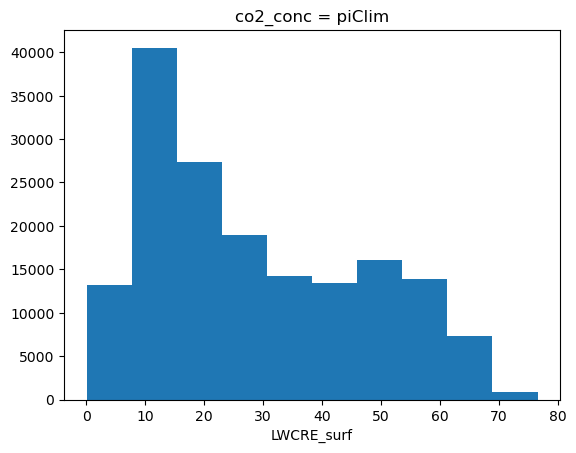

In [110]:
ds['LWCRE_surf'].sel(co2_conc='piClim').plot()

In [61]:
tslice = slice('2040-01-01','2069-12-31')
tempdir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/'

pi_temp = xr.open_dataset(tempdir+'tas_piClim_final30years.nc')
pi_temp = pi_temp.groupby('time.month').mean('time')
pi_temp = pi_temp.rename({'month':'time'})
pi_temp_annavg = pi_temp.mean('time')

experiments = ['abrupt-0_5xCO2', 'abrupt-2xCO2', 'abrupt-4xCO2']
dT_list = []

for exp in experiments:
        temp_ds = xr.open_dataset(tempdir+'tas_'+exp+'_1920-01-01_2069-12-31.nc')

        temp_slice = temp_ds.sel(time=tslice)
        temp_slice = temp_slice.groupby('time.month').mean('time')
        temp_slice = temp_slice.rename({'month':'time'})
        temp_slice['tas'] = temp_slice['tas'] - pi_temp['tas']

        dT_list.append(temp_slice)

ds_dT = xr.concat(dT_list, dim='co2_conc')
ds_dT = ds_dT.assign_coords({'co2_conc':['0.5xCO2', '2xCO2', '4xCO2']})

In [62]:
ds_dT_global_avg = functions.computeWeightedMean(ds_dT)

In [83]:
ds_dT_ann_mean = ds_dT_global_avg.mean('time')

In [90]:
lat_min=70
lat_max=90

ds_Arctic = functions.computeWeightedMean(ds.sel(lat=slice(lat_min,lat_max)))


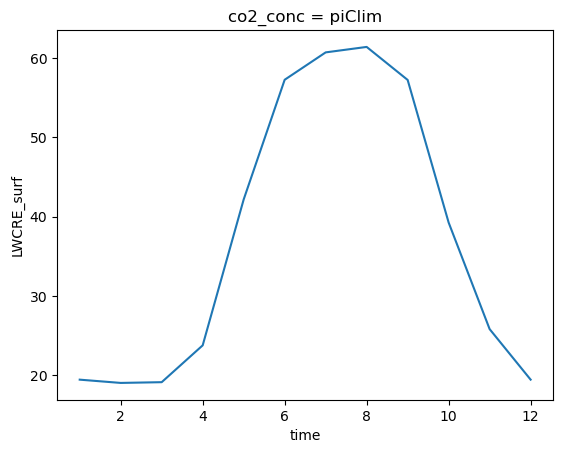

In [111]:
ds_Arctic['LWCRE_surf'].sel(co2_conc='piClim').plot()


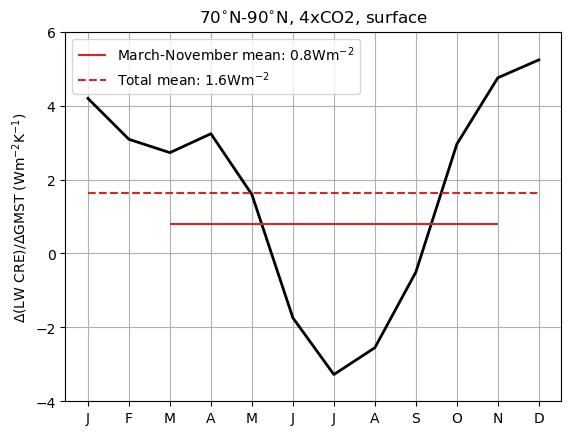

In [108]:
plt.figure()
#for co2_conc, color in zip(['0.5xCO2', '2xCO2', '4xCO2'],['tab:blue', 'tab:orange','tab:red']):
for co2_conc, color in zip(['4xCO2'],['tab:red']):
    march_nov_mean = (ds_Arctic['LWCRE_surf'].sel(co2_conc=co2_conc,time=slice(3,11)) - ds_Arctic['LWCRE_surf'].sel(co2_conc='piClim',time=slice(3,11))).mean('time')/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc)
    total_mean = (ds_Arctic['LWCRE_surf'].sel(co2_conc=co2_conc) - ds_Arctic['LWCRE_surf'].sel(co2_conc='piClim')).mean('time')/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc)

    plt.plot(ds_Arctic['time'],(ds_Arctic['LWCRE_surf'].sel(co2_conc=co2_conc) - ds_Arctic['LWCRE_surf'].sel(co2_conc='piClim'))/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc),color='k',lw=2)
    plt.hlines(march_nov_mean,3,11,color=color,label='March-November mean: '+str(np.round(march_nov_mean.values,1))+'Wm$^{-2}$')
    plt.hlines(total_mean,1,12,linestyle='--',color=color,label='Total mean: '+str(np.round(total_mean.values,1))+'Wm$^{-2}$')


plt.grid()
plt.title(str(lat_min)+'$^{\circ}$N-'+str(lat_max)+'$^{\circ}$N, '+co2_conc+', surface')
plt.xticks(np.arange(1,13,1),['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.ylabel('$\Delta$(LW CRE)/$\Delta$GMST (Wm$^{-2}$K$^{-1}$)')
plt.ylim([-4,6])
plt.legend()

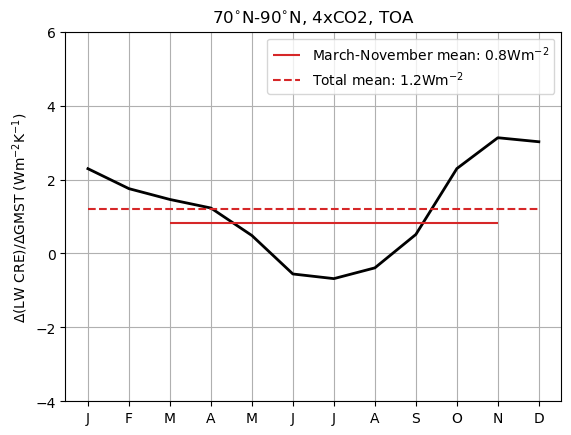

In [107]:
plt.figure()
#for co2_conc, color in zip(['0.5xCO2', '2xCO2', '4xCO2'],['tab:blue', 'tab:orange','tab:red']):
for co2_conc, color in zip(['4xCO2'],['tab:red']):
    march_nov_mean = (ds_Arctic['LWCRE_toa'].sel(co2_conc=co2_conc,time=slice(3,11)) - ds_Arctic['LWCRE_toa'].sel(co2_conc='piClim',time=slice(3,11))).mean('time')/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc)
    total_mean = (ds_Arctic['LWCRE_toa'].sel(co2_conc=co2_conc) - ds_Arctic['LWCRE_toa'].sel(co2_conc='piClim')).mean('time')/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc)

    plt.plot(ds_Arctic['time'],(ds_Arctic['LWCRE_toa'].sel(co2_conc=co2_conc) - ds_Arctic['LWCRE_toa'].sel(co2_conc='piClim'))/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc),color='k',lw=2)
    plt.hlines(march_nov_mean,3,11,color=color,label='March-November mean: '+str(np.round(march_nov_mean.values,1))+'Wm$^{-2}$')
    plt.hlines(total_mean,1,12,linestyle='--',color=color,label='Total mean: '+str(np.round(total_mean.values,1))+'Wm$^{-2}$')

plt.grid()
plt.title(str(lat_min)+'$^{\circ}$N-'+str(lat_max)+'$^{\circ}$N, '+co2_conc+', TOA')
plt.xticks(np.arange(1,13,1),['J','F','M','A','M','J','J','A','S','O','N','D'])
plt.ylabel('$\Delta$(LW CRE)/$\Delta$GMST (Wm$^{-2}$K$^{-1}$)')
plt.ylim([-4,6])
plt.legend()

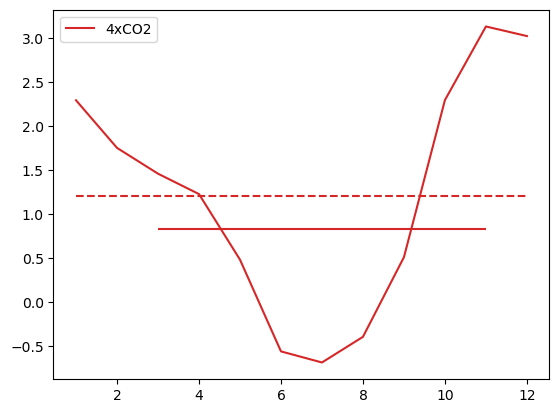

In [ ]:
plt.figure()
for co2_conc, color in zip(['0.5xCO2', '2xCO2', '4xCO2'],['tab:blue', 'tab:orange','tab:red']):
    plt.plot(ds_Arctic['time'],(ds_Arctic['LWCRE_toa'].sel(co2_conc=co2_conc) - ds_Arctic['LWCRE_toa'].sel(co2_conc='piClim'))/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc),label=co2_conc,color=color)
    plt.hlines((ds_Arctic['LWCRE_toa'].sel(co2_conc=co2_conc,time=slice(3,11)) - ds_Arctic['LWCRE_toa'].sel(co2_conc='piClim',time=slice(3,11))).mean('time')/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc),3,11,color=color)
    
plt.hlines((ds_Arctic['LWCRE_toa'].sel(co2_conc=co2_conc) - ds_Arctic['LWCRE_toa'].sel(co2_conc='piClim')).mean('time')/ds_dT_ann_mean['tas'].sel(co2_conc=co2_conc),1,12,linestyle='--',color=color)



plt.legend()